In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

DATA_PATH = r"C:\Users\CS-Admin\Documents\humor-harm-api\unified_dataset.csv"
# Or on Linux:
# DATA_PATH = "/home/kiwi-pandas/Documents/humor-harm-api/unified_dataset.csv"

df = pd.read_csv(DATA_PATH, dtype=str)

print("Shape:", df.shape)
display(df.head())
print("\nColumns:")
print(df.columns.tolist())

Shape: (1211, 27)


,id,transcript_text,dark_intensity,humor_presence,humor_type,joke_topic,rhetorical_device,stand_up,target_category,note,video_id,url,title,description,tags,channel,channel_id,uploader,uploader_id,upload_date,duration,view_count,like_count,comment_count,categories,language,searched_keyword
0,1,Imagine Bill Maher being the voice of reason f...,1 - Mild,Humor,Dark Humor,Politics and society,"{""choices"":[""Irony"",""Satire""]}",Yes,Race / Ethnicity,NaN,-xEw-SdaVJ0,https://www.youtube.com/watch?v=-xEw-SdaVJ0,Bill Maher Crushes Woke Culture,NaN,NaN,Red Shorts Politics,UCA51l1PI_lNs-mTo3bmQfEw,Red Shorts Politics,@RedShortsPolitics,20250816,50,1585516,50081,1700,People & Blogs,en-US,Keyword_BillMaherfunny
1,2,I've always been an animal lover. Ever since I...,NaN,Not Humor,None of these,Other,None of these,No,NaN,NaN,XDuGBcv_R80,https://www.youtube.com/watch?v=XDuGBcv_R80,Her Parents Hated DOGS?!?! 😳 #jaidenanimations...,Her Parents Hated DOGS?!?! 😳 #jaidenanimations...,NaN,GlamourTV-1,UCW-4jz8O0yTKWNYx6lsI9tQ,GlamourTV-1,@GlamourTV-1,20250609,58,55179,NaN,7,People & Blogs,en,Keyword_JaidenAnimationsfunny
2,3,Quagmire. I'm going to get unbanned from hinge...,NaN,Not Humor,None of these,Celebrity and pop culture,None of these,No,NaN,NaN,XF5atSzGKRI,https://www.youtube.com/watch?v=XF5atSzGKRI,Seth MacFarlane switches voices effortlessly,Seth MacFarlane switches voices effortlessly,NaN,Gossip 0791,UCStY6tSbOjaxPEpcTfk5_Rw,Gossip 0791,@Gossip0791,20251014,59,42781021,1412321,3700,People & Blogs,en,Keyword_TheLateNightShowfunny
3,4,"This is terrifying. Oh no, oh no. Oh! Oh! Oh. ...",NaN,Almost or not sure,None of these,Other,None of these,No,NaN,NaN,XNtTO_339kU,https://www.youtube.com/watch?v=XNtTO_339kU,"Pick The Wrong Tube, Get Slimed",NaN,NaN,MrBeast,UCX6OQ3DkcsbYNE6H8uQQuVA,MrBeast,@MrBeast,20250827,35,130134357,2913478,8800,Entertainment,en,Keyword_MrBeastfunny
4,5,उगर्टा है? � oui jan off cro Likeogy ad Search...,NaN,Humor,Regular Humor,Celebrity and pop culture,None of these,No,NaN,Not English,XPx_U-Gw5II,https://www.youtube.com/watch?v=XPx_U-Gw5II,#BabyJohn Stars Join the Fun This Weekend Only...,#BabyJohn Stars Join the Fun This Weekend Only...,kapil sharma|kapil sharma show|the great india...,Kapil Sharma,UC1-BQ2oxqBVtCjMHF-Wf98w,Kapil Sharma,@KapilSharmaK9,20241212,13,24433305,645465,1000,Entertainment,NaN,Keyword_TheLateNightShowfunny



Columns:
['id', 'transcript_text', 'dark_intensity', 'humor_presence', 'humor_type', 'joke_topic', 'rhetorical_device', 'stand_up', 'target_category', 'note', 'video_id', 'url', 'title', 'description', 'tags', 'channel', 'channel_id', 'uploader', 'uploader_id', 'upload_date', 'duration', 'view_count', 'like_count', 'comment_count', 'categories', 'language', 'searched_keyword']


In [4]:
def pick_col(cols, candidates):
    cols_lower = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    for cand in candidates:
        for c in cols:
            if cand.lower() in c.lower():
                return c
    return None

def to_num(series):
    return pd.to_numeric(
        series.astype("string").str.replace(",", "", regex=False).str.strip(),
        errors="coerce"
    )

def word_count(series):
    return (
        series.astype("string")
        .fillna("")
        .str.split()
        .str.len()
    )

cols = df.columns.tolist()

label_col = pick_col(cols, ["label", "humor_type", "category", "class"])
dark_col = pick_col(cols, ["dark_humor", "is_dark_humor", "dark"])
harm_col = pick_col(cols, ["harmful", "is_harmful", "harm", "harm_label"])
transcript_col = pick_col(cols, ["transcript", "video_transcript"])
description_col = pick_col(cols, ["description", "video_description"])
title_col = pick_col(cols, ["title", "video_title"])
views_col = pick_col(cols, ["views", "view_count"])
likes_col = pick_col(cols, ["likes", "like_count"])
comments_col = pick_col(cols, ["comments", "comment_count"])
duration_col = pick_col(cols, ["duration", "duration_seconds", "video_duration"])

print("Detected columns:")
print("label_col      =", label_col)
print("dark_col       =", dark_col)
print("harm_col       =", harm_col)
print("transcript_col =", transcript_col)
print("description_col=", description_col)
print("title_col      =", title_col)
print("views_col      =", views_col)
print("likes_col      =", likes_col)
print("comments_col   =", comments_col)
print("duration_col   =", duration_col)

Detected columns:
label_col      = humor_type
dark_col       = dark_intensity
harm_col       = None
transcript_col = transcript_text
description_col= description
title_col      = title
views_col      = view_count
likes_col      = like_count
comments_col   = comment_count
duration_col   = duration


In [5]:
if transcript_col:
    df["transcript_word_count"] = word_count(df[transcript_col])

if description_col:
    df["description_word_count"] = word_count(df[description_col])

if title_col:
    df["title_word_count"] = word_count(df[title_col])

for old_col, new_col in [
    (views_col, "views_num"),
    (likes_col, "likes_num"),
    (comments_col, "comments_num"),
    (duration_col, "duration_num"),
]:
    if old_col:
        df[new_col] = to_num(df[old_col])

display(df.head())

,id,transcript_text,dark_intensity,humor_presence,humor_type,joke_topic,rhetorical_device,stand_up,target_category,note,video_id,url,title,description,tags,channel,channel_id,uploader,uploader_id,upload_date,duration,view_count,like_count,comment_count,categories,language,searched_keyword,transcript_word_count,description_word_count,title_word_count,views_num,likes_num,comments_num,duration_num
0,1,Imagine Bill Maher being the voice of reason f...,1 - Mild,Humor,Dark Humor,Politics and society,"{""choices"":[""Irony"",""Satire""]}",Yes,Race / Ethnicity,NaN,-xEw-SdaVJ0,https://www.youtube.com/watch?v=-xEw-SdaVJ0,Bill Maher Crushes Woke Culture,NaN,NaN,Red Shorts Politics,UCA51l1PI_lNs-mTo3bmQfEw,Red Shorts Politics,@RedShortsPolitics,20250816,50,1585516,50081,1700,People & Blogs,en-US,Keyword_BillMaherfunny,165,0,5,1585516,50081,1700,50
1,2,I've always been an animal lover. Ever since I...,NaN,Not Humor,None of these,Other,None of these,No,NaN,NaN,XDuGBcv_R80,https://www.youtube.com/watch?v=XDuGBcv_R80,Her Parents Hated DOGS?!?! 😳 #jaidenanimations...,Her Parents Hated DOGS?!?! 😳 #jaidenanimations...,NaN,GlamourTV-1,UCW-4jz8O0yTKWNYx6lsI9tQ,GlamourTV-1,@GlamourTV-1,20250609,58,55179,NaN,7,People & Blogs,en,Keyword_JaidenAnimationsfunny,205,12,12,55179,<NA>,7,58
2,3,Quagmire. I'm going to get unbanned from hinge...,NaN,Not Humor,None of these,Celebrity and pop culture,None of these,No,NaN,NaN,XF5atSzGKRI,https://www.youtube.com/watch?v=XF5atSzGKRI,Seth MacFarlane switches voices effortlessly,Seth MacFarlane switches voices effortlessly,NaN,Gossip 0791,UCStY6tSbOjaxPEpcTfk5_Rw,Gossip 0791,@Gossip0791,20251014,59,42781021,1412321,3700,People & Blogs,en,Keyword_TheLateNightShowfunny,158,5,5,42781021,1412321,3700,59
3,4,"This is terrifying. Oh no, oh no. Oh! Oh! Oh. ...",NaN,Almost or not sure,None of these,Other,None of these,No,NaN,NaN,XNtTO_339kU,https://www.youtube.com/watch?v=XNtTO_339kU,"Pick The Wrong Tube, Get Slimed",NaN,NaN,MrBeast,UCX6OQ3DkcsbYNE6H8uQQuVA,MrBeast,@MrBeast,20250827,35,130134357,2913478,8800,Entertainment,en,Keyword_MrBeastfunny,101,0,6,130134357,2913478,8800,35
4,5,उगर्टा है? � oui jan off cro Likeogy ad Search...,NaN,Humor,Regular Humor,Celebrity and pop culture,None of these,No,NaN,Not English,XPx_U-Gw5II,https://www.youtube.com/watch?v=XPx_U-Gw5II,#BabyJohn Stars Join the Fun This Weekend Only...,#BabyJohn Stars Join the Fun This Weekend Only...,kapil sharma|kapil sharma show|the great india...,Kapil Sharma,UC1-BQ2oxqBVtCjMHF-Wf98w,Kapil Sharma,@KapilSharmaK9,20241212,13,24433305,645465,1000,Entertainment,NaN,Keyword_TheLateNightShowfunny,27,118,12,24433305,645465,1000,13


In [6]:
summary_cols = [
    c for c in [
        "transcript_word_count",
        "description_word_count",
        "title_word_count",
        "views_num",
        "likes_num",
        "comments_num",
        "duration_num"
    ] if c in df.columns
]

display(df[summary_cols].describe().T)


,count,mean,std,min,25%,50%,75%,max
transcript_word_count,1211.0,140.649876,106.578344,0.0,71.0,126.0,180.0,877.0
description_word_count,1211.0,34.236168,73.208738,0.0,0.0,4.0,36.5,694.0
title_word_count,1211.0,8.614368,3.352427,0.0,6.0,8.0,11.0,21.0
views_num,1209.0,15240091.379653,52867919.442468,10313.0,301631.0,2225007.0,8980952.0,680958469.0
likes_num,1102.0,342976.951906,1028681.322371,17.0,8255.5,71887.5,280053.0,16804707.0
comments_num,1125.0,1866.111111,3738.281075,1.0,121.0,609.0,1900.0,49000.0
duration_num,1209.0,53.878412,36.218445,3.0,31.0,48.0,60.0,180.0


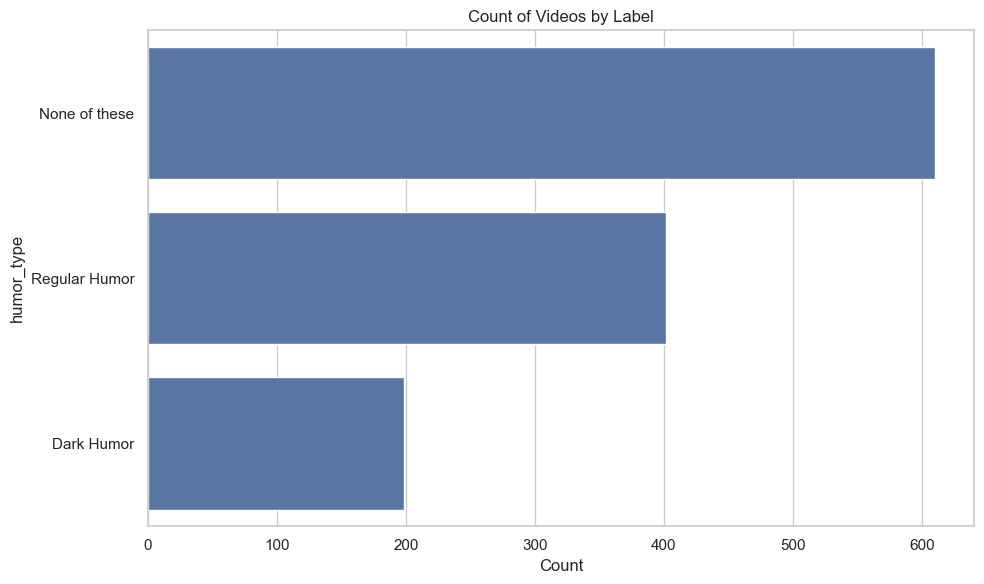

In [7]:
if label_col:
    plt.figure(figsize=(10, 6))
    order = df[label_col].astype("string").value_counts().index
    sns.countplot(data=df, y=label_col, order=order)
    plt.title("Count of Videos by Label")
    plt.xlabel("Count")
    plt.ylabel(label_col)
    plt.tight_layout()
    plt.show()
else:
    print("No label style column found.")

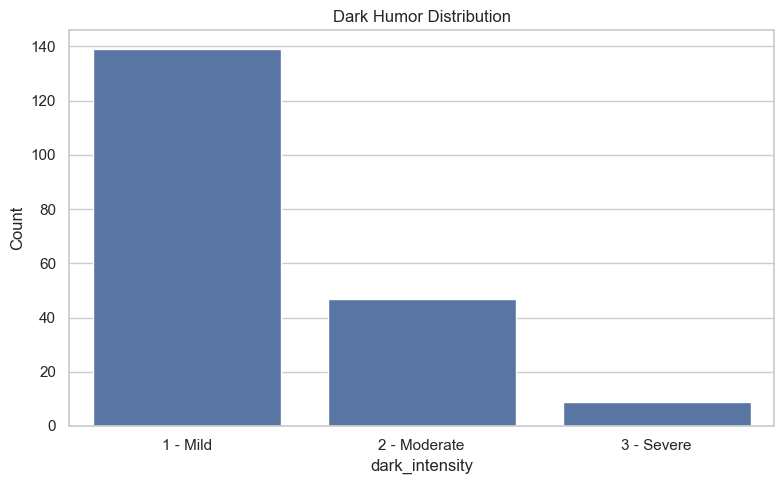

In [8]:
if dark_col:
    plt.figure(figsize=(8, 5))
    order = df[dark_col].astype("string").value_counts().index
    sns.countplot(data=df, x=dark_col, order=order)
    plt.title("Dark Humor Distribution")
    plt.xlabel(dark_col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
else:
    print("No dark humor column found.")

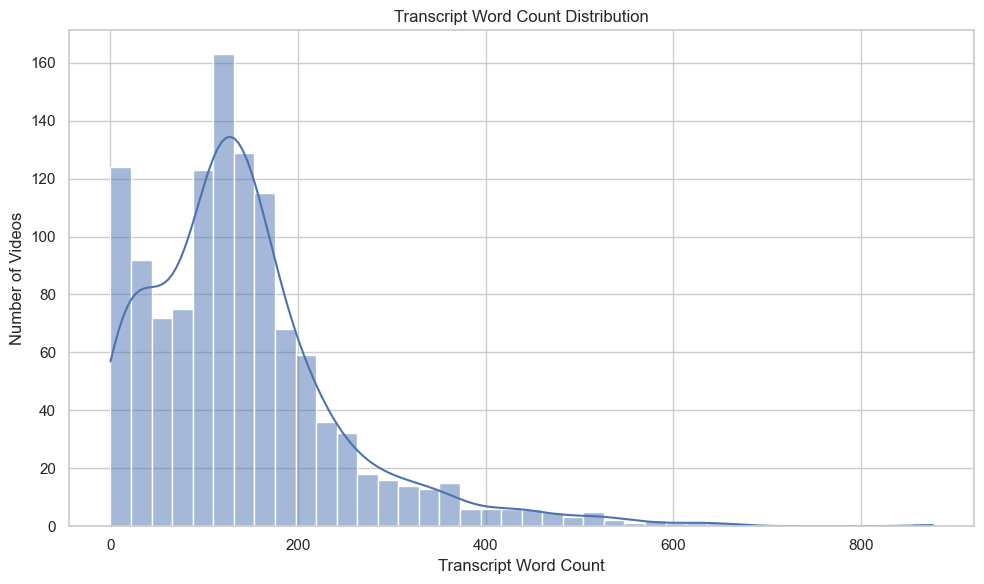

In [9]:
if "transcript_word_count" in df.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(df["transcript_word_count"], bins=40, kde=True)
    plt.title("Transcript Word Count Distribution")
    plt.xlabel("Transcript Word Count")
    plt.ylabel("Number of Videos")
    plt.tight_layout()
    plt.show()
else:
    print("Transcript word count not available.")

In [10]:
for col in num_plot_cols:
    temp = df[[col]].copy()
    temp = temp[temp[col].notna() & (temp[col] > 0)]
    
    if len(temp) > 0:
        plt.figure(figsize=(10, 5))
        sns.histplot(np.log10(temp[col]), bins=40, kde=True)
        plt.title(f"Log Distribution of {col}")
        plt.xlabel(f"log10({col})")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()

NameError: name 'num_plot_cols' is not defined

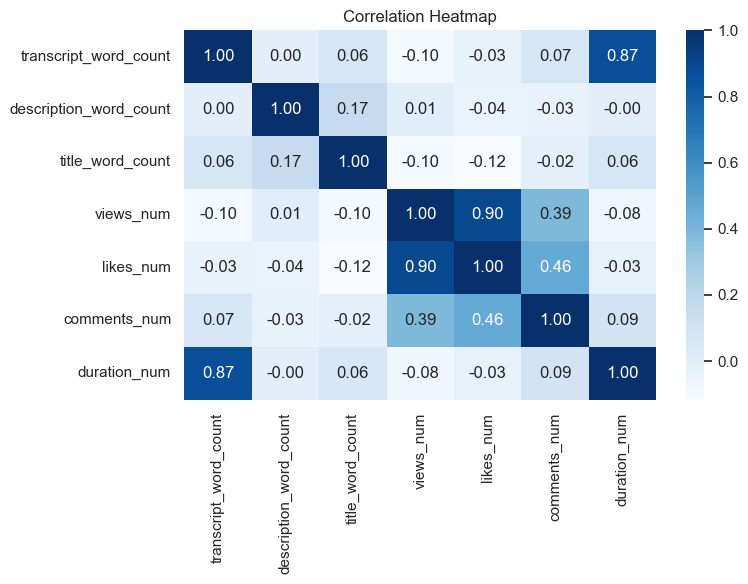

In [ ]:
numeric_cols = [c for c in [
    "transcript_word_count",
    "description_word_count",
    "title_word_count",
    "views_num",
    "likes_num",
    "comments_num",
    "duration_num"
] if c in df.columns]

if len(numeric_cols) >= 2:
    corr = df[numeric_cols].corr(numeric_only=True)

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric columns for a heatmap.")

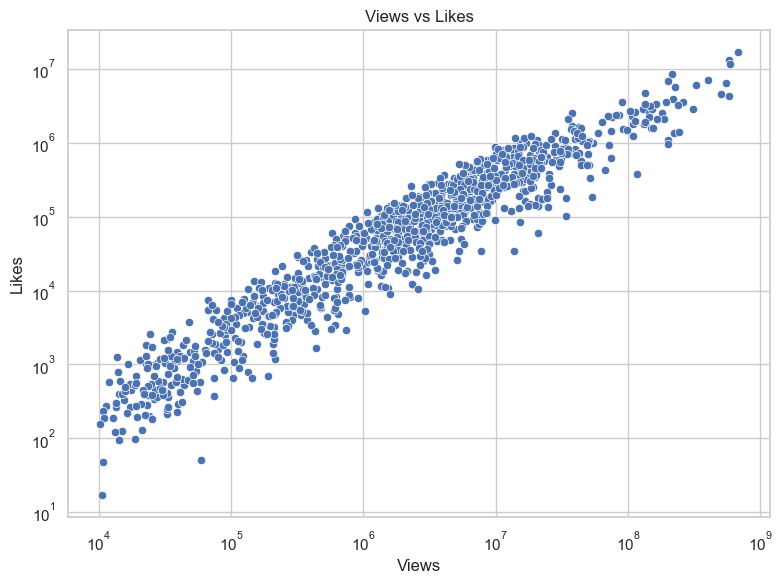

In [ ]:
if "views_num" in df.columns and "likes_num" in df.columns:
    temp = df[["views_num", "likes_num"]].dropna().copy()
    temp = temp[(temp["views_num"] > 0) & (temp["likes_num"] > 0)]
    
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=temp, x="views_num", y="likes_num")
    plt.xscale("log")
    plt.yscale("log")
    plt.title("Views vs Likes")
    plt.xlabel("Views")
    plt.ylabel("Likes")
    plt.tight_layout()
    plt.show()
else:
    print("Views and likes columns not available.")

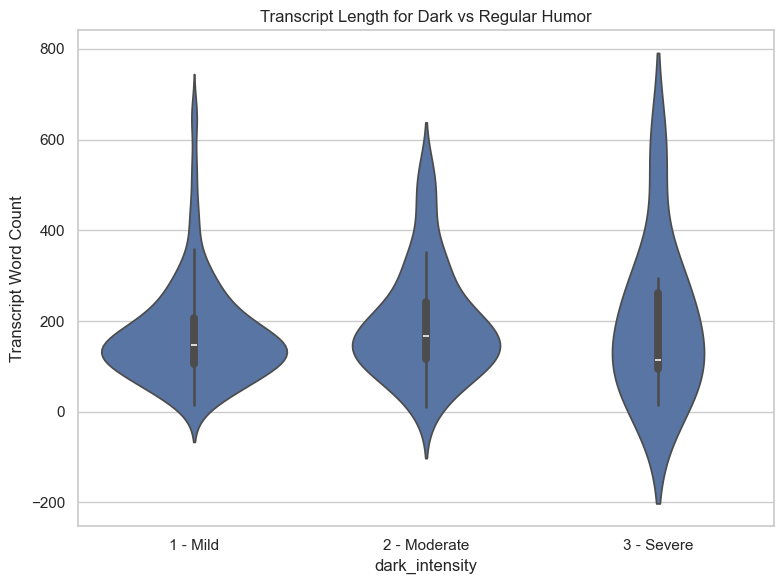

In [ ]:
if dark_col and "transcript_word_count" in df.columns:
    plt.figure(figsize=(8, 6))
    sns.violinplot(data=df, x=dark_col, y="transcript_word_count")
    plt.title("Transcript Length for Dark vs Regular Humor")
    plt.xlabel(dark_col)
    plt.ylabel("Transcript Word Count")
    plt.tight_layout()
    plt.show()
else:
    print("Need dark humor column and transcript word counts.")

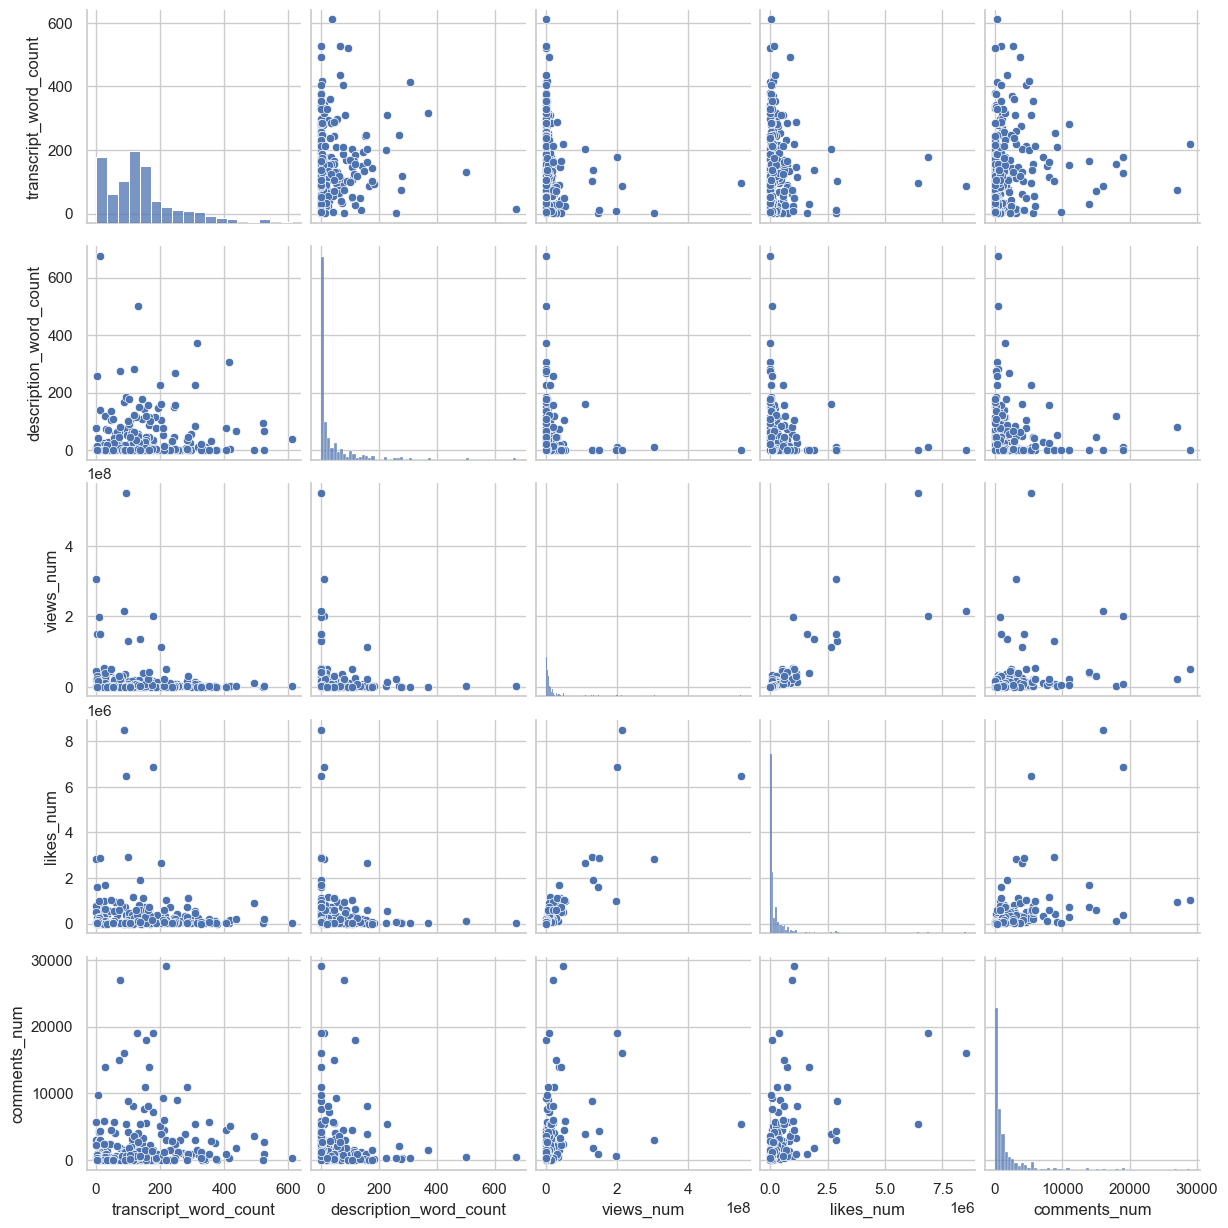

In [ ]:
pairplot_cols = [c for c in [
    "transcript_word_count",
    "description_word_count",
    "views_num",
    "likes_num",
    "comments_num"
] if c in df.columns]

if len(pairplot_cols) >= 2:
    sns.pairplot(df[pairplot_cols].dropna().sample(min(300, len(df.dropna(subset=pairplot_cols))), random_state=42))
    plt.show()
else:
    print("Not enough columns for pairplot.")

humor_col = humor_type
dark_col  = dark_intensity
humor_col = humor_type


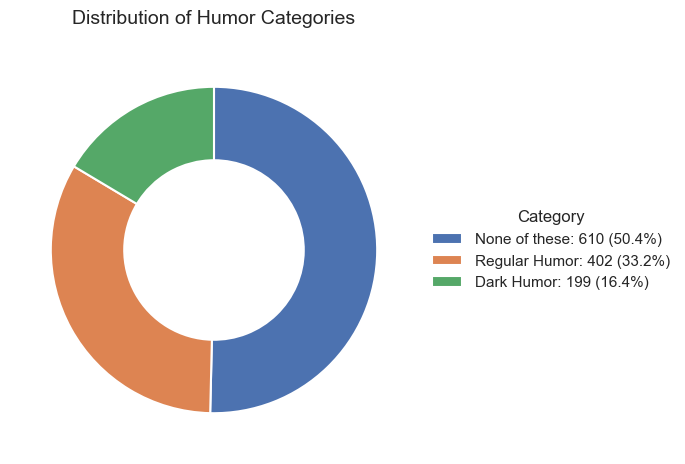

In [11]:
def pick_col(cols, candidates):
    cols_lower = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    for cand in candidates:
        for c in cols:
            if cand.lower() in c.lower():
                return c
    return None

cols = df.columns.tolist()

humor_col = pick_col(cols, ["humor_type", "label", "category", "class"])
dark_col = pick_col(cols, ["dark_humor", "is_dark_humor", "dark"])

print("humor_col =", humor_col)
print("dark_col  =", dark_col)

import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

def pick_col(cols, candidates):
    cols_lower = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    for cand in candidates:
        for c in cols:
            if cand.lower() in c.lower():
                return c
    return None

cols = df.columns.tolist()
humor_col = pick_col(cols, ["humor_type", "label", "category", "class"])

print("humor_col =", humor_col)

import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

if humor_col:
    humor_counts = (
        df[humor_col]
        .astype("string")
        .fillna("Missing")
        .str.strip()
        .replace("", "Missing")
        .value_counts()
    )

    total = humor_counts.sum()
    legend_labels = [
        f"{label}: {count} ({count / total * 100:.1f}%)"
        for label, count in humor_counts.items()
    ]

    fig, ax = plt.subplots(figsize=(7, 7), facecolor="white")

    wedges, _ = ax.pie(
        humor_counts.values,
        startangle=90,
        counterclock=False,
        wedgeprops=dict(width=0.45, edgecolor="white", linewidth=1.5)
    )

    ax.set_title("Distribution of Humor Categories", fontsize=14, pad=16)
    ax.legend(
        wedges,
        legend_labels,
        title="Category",
        loc="center left",
        bbox_to_anchor=(1, 0.5),
        frameon=False
    )

    plt.tight_layout()
    plt.show()

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math

sns.set_theme(style="whitegrid")

# If df is not already loaded, uncomment one of these:
# df = pd.read_csv(r"C:\Users\CS-Admin\Documents\humor-harm-api\unified_dataset.csv")
# df = pd.read_csv("/home/kiwi-pandas/Documents/humor-harm-api/unified_dataset.csv")

print(df.shape)
display(df.head())

df_plot = df.copy()

for col in df_plot.columns:
    cleaned = (
        df_plot[col]
        .astype("string")
        .str.replace(",", "", regex=False)
        .str.strip()
    )
    converted = pd.to_numeric(cleaned, errors="coerce")
    
    # only convert if enough values become numeric
    if converted.notna().sum() > 0 and converted.notna().sum() >= 0.6 * len(df_plot):
        df_plot[col] = converted

print(df_plot.dtypes)


(1211, 35)


,id,transcript_text,dark_intensity,humor_presence,humor_type,joke_topic,rhetorical_device,stand_up,target_category,note,video_id,url,title,description,tags,channel,channel_id,uploader,uploader_id,upload_date,duration,view_count,like_count,comment_count,categories,language,searched_keyword,transcript_word_count,description_word_count,title_word_count,views_num,likes_num,comments_num,duration_num,dark_group
0,1,Imagine Bill Maher being the voice of reason f...,1 - Mild,Humor,Dark Humor,Politics and society,"{""choices"":[""Irony"",""Satire""]}",Yes,Race / Ethnicity,NaN,-xEw-SdaVJ0,https://www.youtube.com/watch?v=-xEw-SdaVJ0,Bill Maher Crushes Woke Culture,NaN,NaN,Red Shorts Politics,UCA51l1PI_lNs-mTo3bmQfEw,Red Shorts Politics,@RedShortsPolitics,20250816,50,1585516,50081,1700,People & Blogs,en-US,Keyword_BillMaherfunny,165,0,5,1585516,50081,1700,50,1 - mild
1,2,I've always been an animal lover. Ever since I...,NaN,Not Humor,None of these,Other,None of these,No,NaN,NaN,XDuGBcv_R80,https://www.youtube.com/watch?v=XDuGBcv_R80,Her Parents Hated DOGS?!?! 😳 #jaidenanimations...,Her Parents Hated DOGS?!?! 😳 #jaidenanimations...,NaN,GlamourTV-1,UCW-4jz8O0yTKWNYx6lsI9tQ,GlamourTV-1,@GlamourTV-1,20250609,58,55179,NaN,7,People & Blogs,en,Keyword_JaidenAnimationsfunny,205,12,12,55179,<NA>,7,58,Missing
2,3,Quagmire. I'm going to get unbanned from hinge...,NaN,Not Humor,None of these,Celebrity and pop culture,None of these,No,NaN,NaN,XF5atSzGKRI,https://www.youtube.com/watch?v=XF5atSzGKRI,Seth MacFarlane switches voices effortlessly,Seth MacFarlane switches voices effortlessly,NaN,Gossip 0791,UCStY6tSbOjaxPEpcTfk5_Rw,Gossip 0791,@Gossip0791,20251014,59,42781021,1412321,3700,People & Blogs,en,Keyword_TheLateNightShowfunny,158,5,5,42781021,1412321,3700,59,Missing
3,4,"This is terrifying. Oh no, oh no. Oh! Oh! Oh. ...",NaN,Almost or not sure,None of these,Other,None of these,No,NaN,NaN,XNtTO_339kU,https://www.youtube.com/watch?v=XNtTO_339kU,"Pick The Wrong Tube, Get Slimed",NaN,NaN,MrBeast,UCX6OQ3DkcsbYNE6H8uQQuVA,MrBeast,@MrBeast,20250827,35,130134357,2913478,8800,Entertainment,en,Keyword_MrBeastfunny,101,0,6,130134357,2913478,8800,35,Missing
4,5,उगर्टा है? � oui jan off cro Likeogy ad Search...,NaN,Humor,Regular Humor,Celebrity and pop culture,None of these,No,NaN,Not English,XPx_U-Gw5II,https://www.youtube.com/watch?v=XPx_U-Gw5II,#BabyJohn Stars Join the Fun This Weekend Only...,#BabyJohn Stars Join the Fun This Weekend Only...,kapil sharma|kapil sharma show|the great india...,Kapil Sharma,UC1-BQ2oxqBVtCjMHF-Wf98w,Kapil Sharma,@KapilSharmaK9,20241212,13,24433305,645465,1000,Entertainment,NaN,Keyword_TheLateNightShowfunny,27,118,12,24433305,645465,1000,13,Missing


id                                 Int64
transcript_text                   object
dark_intensity                    object
humor_presence                    object
humor_type                        object
joke_topic                        object
rhetorical_device                 object
stand_up                          object
target_category                   object
note                              object
video_id                          object
url                               object
title                             object
description                       object
tags                              object
channel                           object
channel_id                        object
uploader                          object
uploader_id                       object
upload_date                        Int64
duration                           Int64
view_count                         Int64
like_count                         Int64
comment_count                      Int64
categories      

In [ ]:
def pick_col(cols, candidates):
    cols_lower = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    for cand in candidates:
        for c in cols:
            if cand.lower() in c.lower():
                return c
    return None

def to_num(series):
    return pd.to_numeric(
        series.astype("string").str.replace(",", "", regex=False).str.strip(),
        errors="coerce"
    )

def word_count(series):
    return (
        series.astype("string")
        .fillna("")
        .str.split()
        .str.len()
    )

def tag_count(series):
    s = series.astype("string").fillna("").str.strip()
    return s.apply(lambda x: 0 if x == "" else len([t for t in x.split(",") if t.strip()]))

cols = df.columns.tolist()

humor_presence_col = pick_col(cols, ["humor_presence"])
stand_up_col = pick_col(cols, ["stand_up"])
target_category_col = pick_col(cols, ["target_category"])
description_col = pick_col(cols, ["description", "video_description"])
tags_col = pick_col(cols, ["tags"])
duration_col = pick_col(cols, ["duration", "duration_seconds", "video_duration"])
view_col = pick_col(cols, ["view_count", "views"])
like_col = pick_col(cols, ["like_count", "likes"])
comment_col = pick_col(cols, ["comment_num", "comment_count", "comments"])

print("humor_presence_col  =", humor_presence_col)
print("stand_up_col        =", stand_up_col)
print("target_category_col =", target_category_col)
print("description_col     =", description_col)
print("tags_col            =", tags_col)
print("duration_col        =", duration_col)
print("view_col            =", view_col)
print("like_col            =", like_col)
print("comment_col         =", comment_col)


humor_presence_col  = humor_presence
stand_up_col        = stand_up
target_category_col = target_category
description_col     = description
tags_col            = tags
duration_col        = duration
view_col            = view_count
like_col            = like_count
comment_col         = comment_count


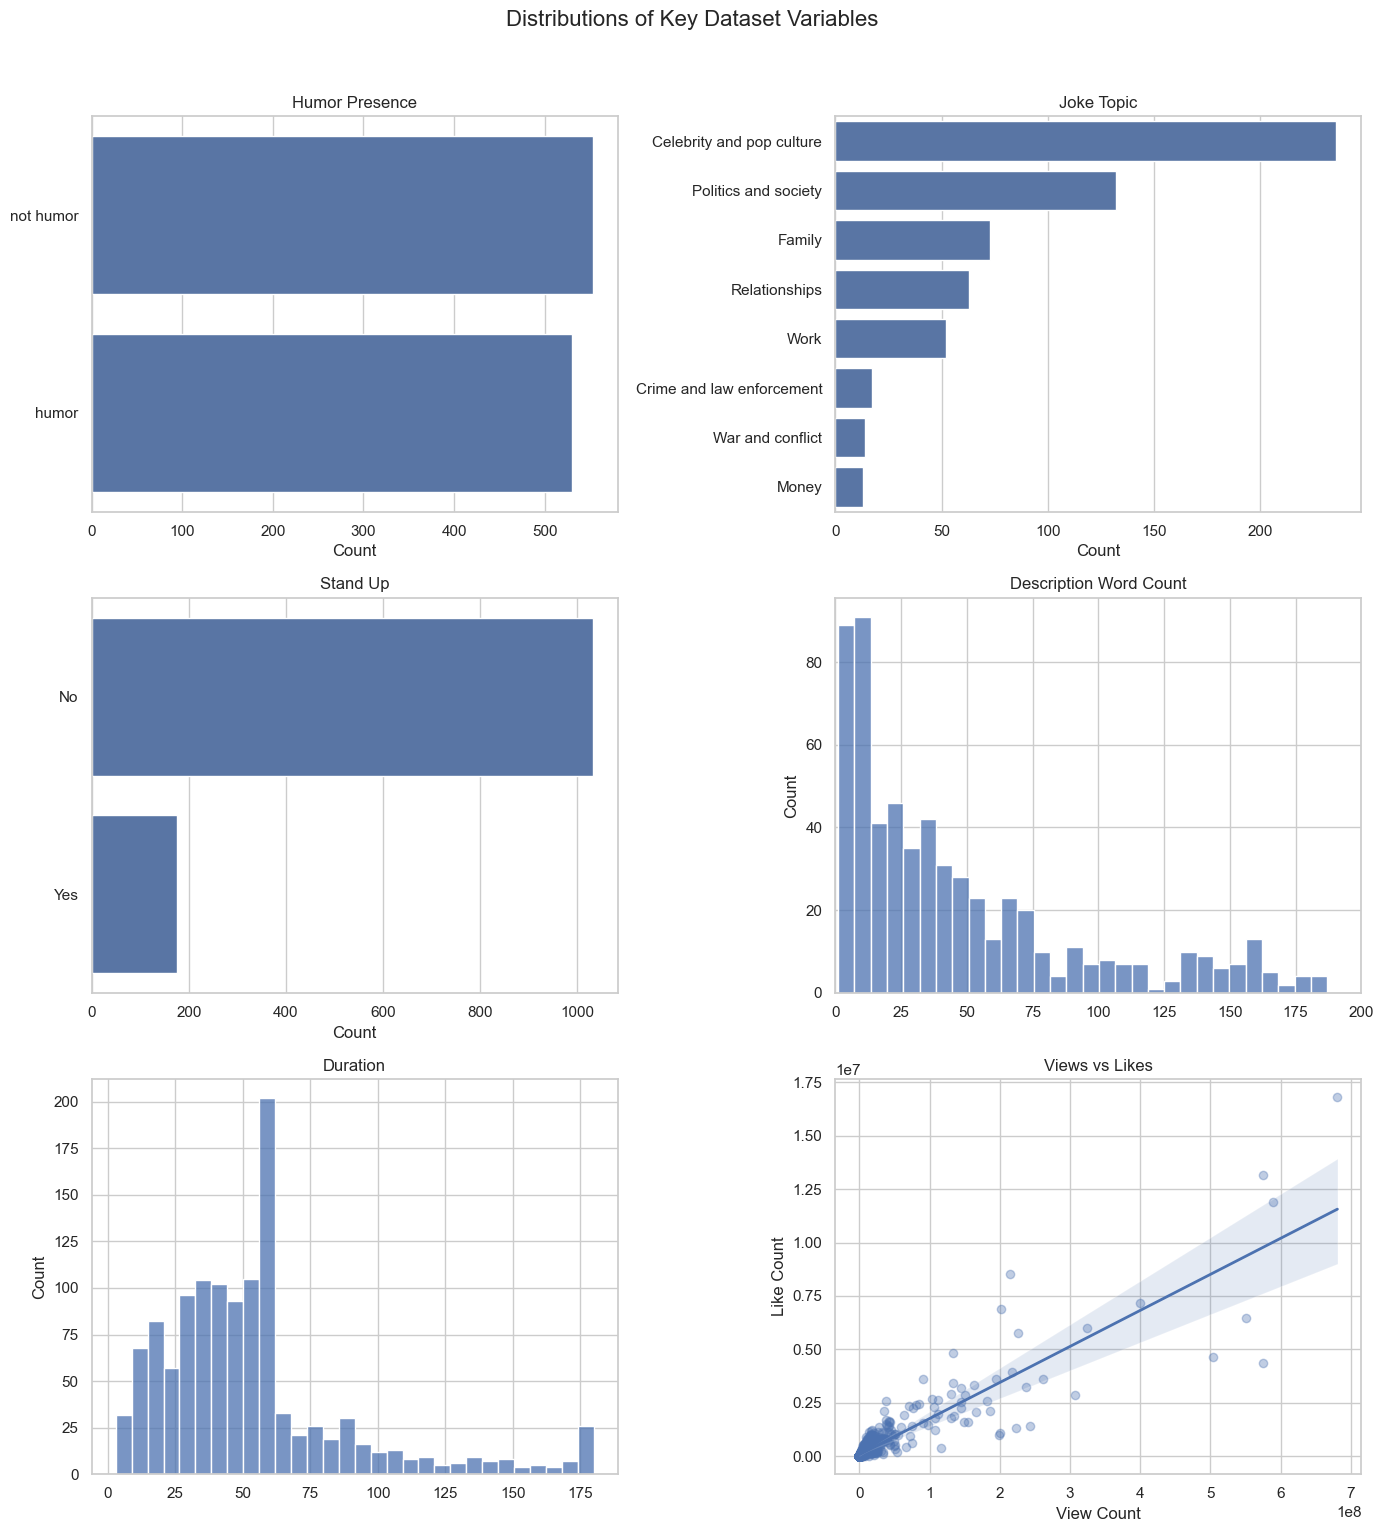

In [88]:
label_map = {
    "humor_presence": "Humor Presence",
    "joke_topic": "Joke Topic",
    "stand_up": "Stand Up",
    "description_word_count": "Description Word Count",
    "tag_count": "Tag Count",
    "duration": "Duration",
    "views_vs_likes": "Views vs Likes"
}

plot_order = [
    "humor_presence",
    "joke_topic",
    "stand_up",
    "description_word_count",
    "duration",
    "views_vs_likes"
]

plot_cols = plot_order.copy()

n_cols = 2
n_rows = 3

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 15))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    ax = axes[i]

    if col == "views_vs_likes":
        scatter_df = plot_df[["view_count", "like_count"]].dropna()
        scatter_df = scatter_df[
            (scatter_df["view_count"] > 0) &
            (scatter_df["like_count"] > 0)
        ]

        sns.regplot(
            data=scatter_df,
            x="view_count",
            y="like_count",
            scatter_kws={"alpha": 0.35},
            line_kws={"linewidth": 2},
            ax=ax
        )
        ax.set_xlabel("View Count")
        ax.set_ylabel("Like Count")
        ax.set_title(label_map[col], fontsize=12)
        continue

    if col not in plot_df.columns:
        fig.delaxes(ax)
        continue

    series = plot_df[col].dropna()

    if pd.api.types.is_numeric_dtype(plot_df[col]):
        temp = series.copy()

        if col == "description_word_count":
            temp = temp[temp <= 200]

        sns.histplot(temp, bins=30, ax=ax)
        ax.set_xlabel("")
        ax.set_ylabel("Count")

        if col == "description_word_count":
            ax.set_xlim(0, 200)

    else:
        counts = series.value_counts()

        if col == "humor_presence":
            counts = counts[counts.index.astype("string").str.strip().str.lower() != "almost"]

        if col == "joke_topic":
            counts = counts[counts.index.astype("string").str.strip().str.lower() != "other"]

        if col == "stand_up":
            counts = counts[counts.index.astype("string").str.strip().str.lower() != "missing"]

        counts = counts.head(8)

        sns.barplot(x=counts.values, y=counts.index, ax=ax)
        ax.set_xlabel("Count")
        ax.set_ylabel("")

    ax.set_title(label_map.get(col, col), fontsize=12)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distributions of Key Dataset Variables", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

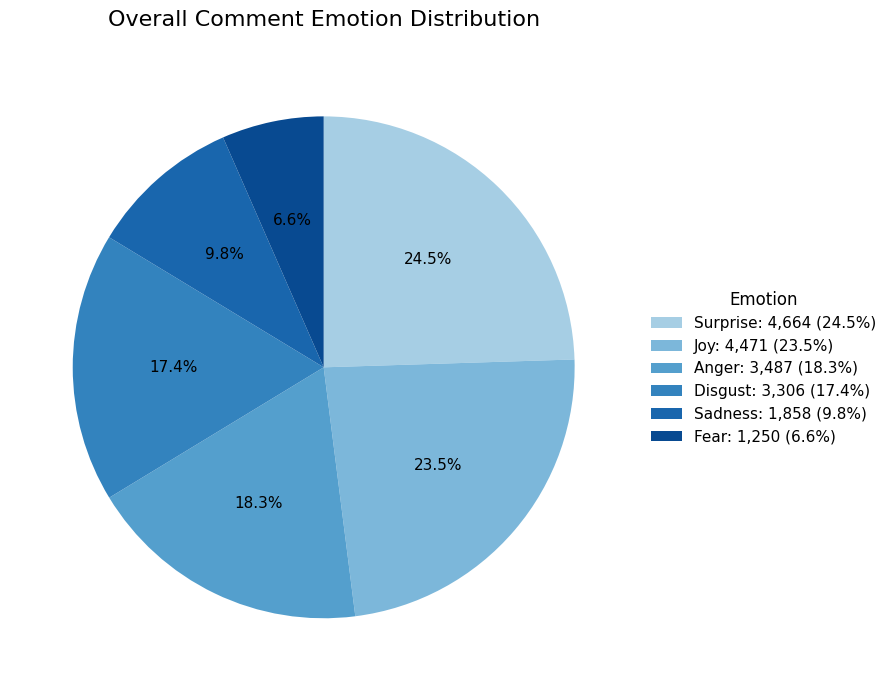

In [1]:
import matplotlib.pyplot as plt
import numpy as np

emotion_counts = {
    "Surprise": 4664,
    "Joy": 4471,
    "Anger": 3487,
    "Disgust": 3306,
    "Sadness": 1858,
    "Fear": 1250
}

labels = list(emotion_counts.keys())
sizes = list(emotion_counts.values())
total = sum(sizes)

# blue palette
colors = plt.cm.Blues(np.linspace(0.35, 0.9, len(sizes)))

legend_labels = [
    f"{label}: {count:,} ({count / total * 100:.1f}%)"
    for label, count in emotion_counts.items()
]

fig, ax = plt.subplots(figsize=(9, 9), facecolor="white")

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=None,
    colors=colors,
    autopct=lambda pct: f"{pct:.1f}%" if pct >= 4 else "",
    startangle=90,
    counterclock=False,
    #wedgeprops=dict(width=0.7, edgecolor="white", linewidth=2),
    textprops=dict(fontsize=11, color="black")
)

#centre_circle = plt.Circle((0, 0), 0.4, fc="white")
#ax.add_artist(centre_circle)

ax.set_title("Overall Comment Emotion Distribution", fontsize=16, pad=20)

ax.legend(
    wedges,
    legend_labels,
    title="Emotion",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=False,
    fontsize=11,
    title_fontsize=12
)

plt.tight_layout()
plt.show()



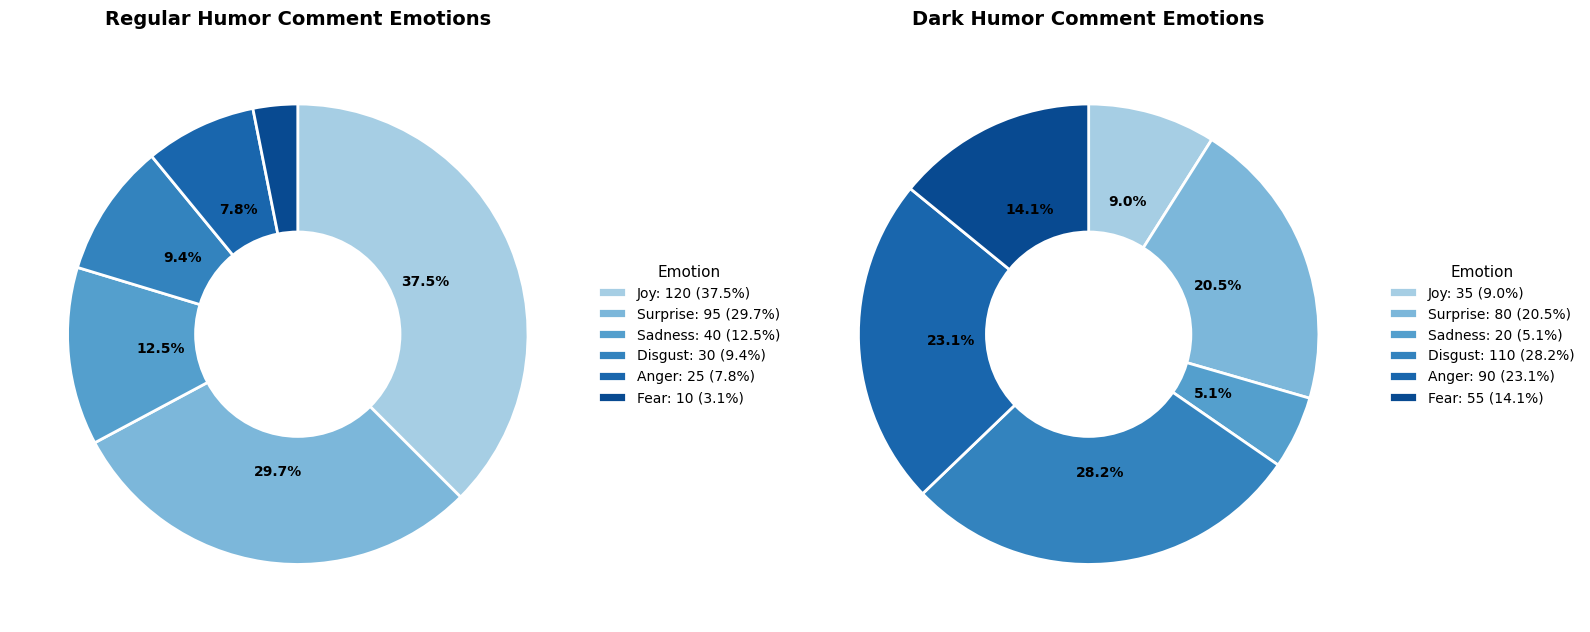

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# replace these with your real counts
regular_counts = {
    "Joy": 120,
    "Surprise": 95,
    "Sadness": 40,
    "Disgust": 30,
    "Anger": 25,
    "Fear": 10
}

dark_counts = {
    "Disgust": 110,
    "Anger": 90,
    "Surprise": 80,
    "Fear": 55,
    "Joy": 35,
    "Sadness": 20
}

# keep a fixed order for comparison
emotion_order = ["Joy", "Surprise", "Sadness", "Disgust", "Anger", "Fear"]

regular_sizes = [regular_counts.get(emotion, 0) for emotion in emotion_order]
dark_sizes = [dark_counts.get(emotion, 0) for emotion in emotion_order]

regular_total = sum(regular_sizes)
dark_total = sum(dark_sizes)

colors = plt.cm.Blues(np.linspace(0.35, 0.9, len(emotion_order)))

fig, axes = plt.subplots(1, 2, figsize=(16, 8), facecolor="white")

# Regular humor chart
regular_legend = [
    f"{emotion}: {count:,} ({count / regular_total * 100:.1f}%)"
    for emotion, count in zip(emotion_order, regular_sizes)
]

wedges1, texts1, autotexts1 = axes[0].pie(
    regular_sizes,
    labels=None,
    colors=colors,
    autopct=lambda pct: f"{pct:.1f}%" if pct >= 4 else "",
    startangle=90,
    counterclock=False,
    wedgeprops=dict(width=0.72, edgecolor="white", linewidth=2),
    textprops=dict(fontsize=10, color="black")
)

for autotext in autotexts1:
    autotext.set_fontsize(10)
    autotext.set_weight("bold")

axes[0].add_artist(plt.Circle((0, 0), 0.45, fc="white"))
axes[0].set_title("Regular Humor Comment Emotions", fontsize=14, weight="bold", pad=16)
axes[0].legend(
    wedges1,
    regular_legend,
    title="Emotion",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=False,
    fontsize=10,
    title_fontsize=11
)

# Dark humor chart
dark_legend = [
    f"{emotion}: {count:,} ({count / dark_total * 100:.1f}%)"
    for emotion, count in zip(emotion_order, dark_sizes)
]

wedges2, texts2, autotexts2 = axes[1].pie(
    dark_sizes,
    labels=None,
    colors=colors,
    autopct=lambda pct: f"{pct:.1f}%" if pct >= 4 else "",
    startangle=90,
    counterclock=False,
    wedgeprops=dict(width=0.72, edgecolor="white", linewidth=2),
    textprops=dict(fontsize=10, color="black")
)

for autotext in autotexts2:
    autotext.set_fontsize(10)
    autotext.set_weight("bold")

axes[1].add_artist(plt.Circle((0, 0), 0.45, fc="white"))
axes[1].set_title("Dark Humor Comment Emotions", fontsize=14, weight="bold", pad=16)
axes[1].legend(
    wedges2,
    dark_legend,
    title="Emotion",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=False,
    fontsize=10,
    title_fontsize=11
)

plt.tight_layout()
plt.show()